# Test-Time Augmentation (TTA) for Uncertainty Quantification

Test-Time Augmentation (TTA) adds UQ to ANY trained model — no architectural changes, no retraining. Apply random perturbations to the input, measure spread of predictions.

If the model is robust to perturbations → low uncertainty. If small input changes cause large output changes → high uncertainty.

This is especially useful for production models that can't be retrained.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from deepuq.models import MLP
from deepuq.methods.tta import TTAWrapper

## Train a Simple Regression Model

In [2]:
np.random.seed(42)
x_train = np.random.uniform(-3, 3, 100).astype(np.float32)
y_train = (np.sin(x_train) + np.random.normal(0, 0.1, 100)).astype(np.float32)
x_test = np.linspace(-5, 5, 200).astype(np.float32)

x_train_t = torch.from_numpy(x_train).unsqueeze(-1)
y_train_t = torch.from_numpy(y_train).unsqueeze(-1)
x_test_t = torch.from_numpy(x_test).unsqueeze(-1)

# Train vanilla MLP
model = MLP(1, [64, 64], 1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = torch.nn.MSELoss()

for epoch in range(300):
    optimizer.zero_grad()
    loss = loss_fn(model(x_train_t), y_train_t)
    loss.backward()
    optimizer.step()

print(f"Final training loss: {loss.item():.4f}")

Final training loss: 0.0064


## Add UQ via TTA

In [3]:
# Create TTA wrapper with noise augmentations at different scales
augmentations = [
    lambda x: x + torch.randn_like(x) * 0.01,
    lambda x: x + torch.randn_like(x) * 0.05,
    lambda x: x + torch.randn_like(x) * 0.1,
    lambda x: x + torch.randn_like(x) * 0.02,
    lambda x: x + torch.randn_like(x) * 0.08,
    lambda x: x + torch.randn_like(x) * 0.03,
    lambda x: x + torch.randn_like(x) * 0.07,
    lambda x: x + torch.randn_like(x) * 0.04,
    lambda x: x + torch.randn_like(x) * 0.06,
    lambda x: x + torch.randn_like(x) * 0.09,
] * 3  # 30 augmentations

tta = TTAWrapper(model, augmentations=augmentations)

# Predict with uncertainty (returns UQResult)
result = tta.predict_uq(x_test_t)
mean = result.mean.numpy().squeeze()
std = result.epistemic_var.sqrt().numpy().squeeze()

## Visualize

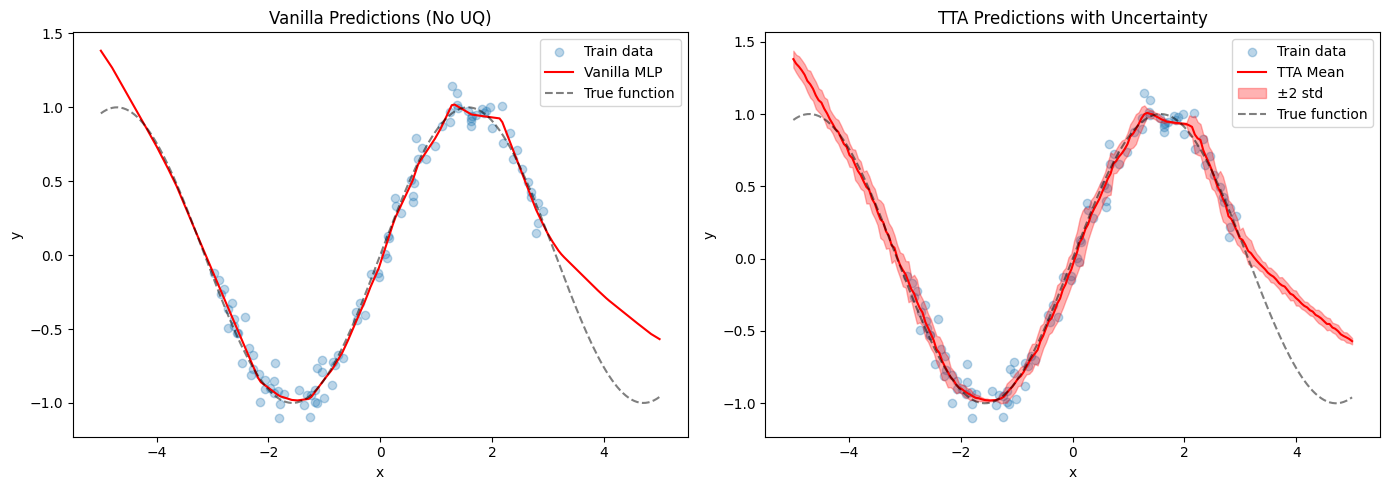

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vanilla predictions
model.eval()
with torch.no_grad():
    vanilla_pred = model(x_test_t).numpy().squeeze()

axes[0].scatter(x_train, y_train, alpha=0.3, label="Train data")
axes[0].plot(x_test, vanilla_pred, "r-", label="Vanilla MLP")
axes[0].plot(x_test, np.sin(x_test), "k--", alpha=0.5, label="True function")
axes[0].set_title("Vanilla Predictions (No UQ)")
axes[0].legend()
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# TTA predictions
axes[1].scatter(x_train, y_train, alpha=0.3, label="Train data")
axes[1].plot(x_test, mean, "r-", label="TTA Mean")
axes[1].fill_between(x_test, mean - 2*std, mean + 2*std, alpha=0.3, color="red", label="±2 std")
axes[1].plot(x_test, np.sin(x_test), "k--", alpha=0.5, label="True function")
axes[1].set_title("TTA Predictions with Uncertainty")
axes[1].legend()
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()

### Custom Augmentation Strategies

Different augmentation types capture different uncertainty sources:
- **Additive noise**: sensitivity to measurement error
- **Scaling**: sensitivity to feature magnitude / units
- **Dropout-style masking**: sensitivity to missing features

Combining multiple augmentation types gives a richer uncertainty estimate that covers more failure modes.

## Custom Augmentations

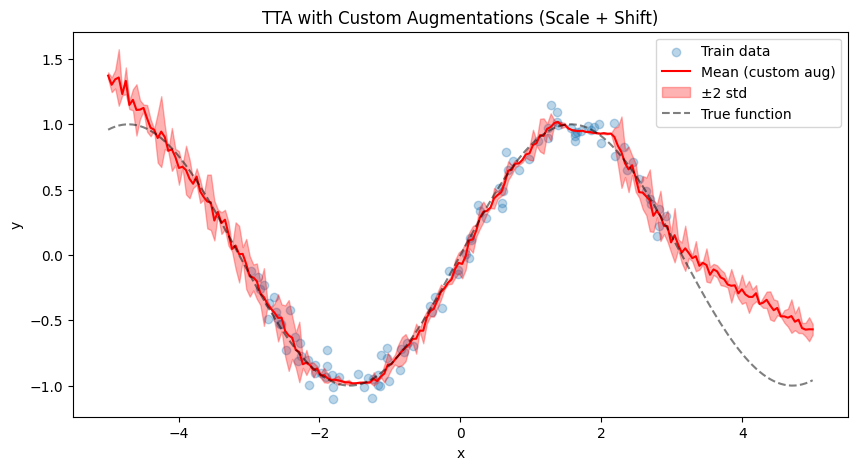

In [5]:
# Define custom augmentation functions
def scale_augmentation(x, scale_range=(0.95, 1.05)):
    scale = torch.empty(x.shape).uniform_(*scale_range)
    return x * scale

def shift_augmentation(x, shift_range=(-0.1, 0.1)):
    shift = torch.empty(x.shape).uniform_(*shift_range)
    return x + shift

# Use custom augmentations
tta_custom = TTAWrapper(model, augmentations=[scale_augmentation, shift_augmentation])

result_custom = tta_custom.predict_uq(x_test_t)
mean_custom = result_custom.mean.numpy().squeeze()
std_custom = result_custom.epistemic_var.sqrt().numpy().squeeze()

plt.figure(figsize=(10, 5))
plt.scatter(x_train, y_train, alpha=0.3, label="Train data")
plt.plot(x_test, mean_custom, "r-", label="Mean (custom aug)")
plt.fill_between(x_test, mean_custom - 2*std_custom, mean_custom + 2*std_custom,
                 alpha=0.3, color="red", label="\u00b12 std")
plt.plot(x_test, np.sin(x_test), "k--", alpha=0.5, label="True function")
plt.legend()
plt.title("TTA with Custom Augmentations (Scale + Shift)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()